<a href="https://colab.research.google.com/github/oninonins/Machine-learning-/blob/main/Js4_tugas_DBSCAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import numpy as np
import pandas as pd

from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn import metrics

In [3]:
#dataset
X, labels_true = make_moons(n_samples=1000, noise=0.05, random_state=0)

In [4]:
#normalisasi data
X = StandardScaler().fit_transform(X)

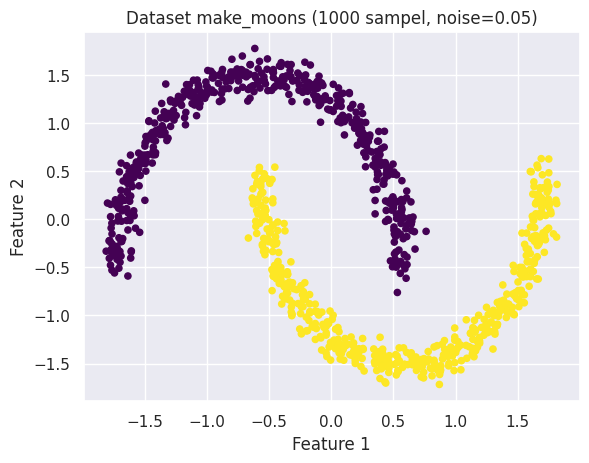

In [5]:
#visualisasi data
plt.scatter(X[:, 0], X[:, 1], c=labels_true, s=20, cmap='viridis')
plt.title('Dataset make_moons (1000 sampel, noise=0.05)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [6]:
#DBSCAN
db = DBSCAN(eps=0.2, min_samples=5).fit(X)
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 2
Estimated number of noise points: 0


In [7]:
#evaluasi
print(f"Homogeneity: {metrics.homogeneity_score(labels_true, labels):.3f}")
print(f"Completeness: {metrics.completeness_score(labels_true, labels):.3f}")
print(f"V-measure: {metrics.v_measure_score(labels_true, labels):.3f}")
print(f"Adjusted Rand Index: {metrics.adjusted_rand_score(labels_true, labels):.3f}")
print(
    "Adjusted Mutual Information:"
    f" {metrics.adjusted_mutual_info_score(labels_true, labels):.3f}"
)
print(f"Silhouette Coefficient: {metrics.silhouette_score(X, labels):.3f}")

Homogeneity: 1.000
Completeness: 1.000
V-measure: 1.000
Adjusted Rand Index: 1.000
Adjusted Mutual Information: 1.000
Silhouette Coefficient: 0.392


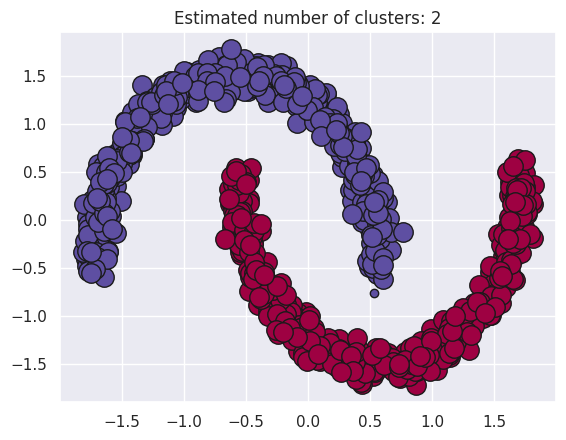

In [8]:
#visulisasi hasil
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()

In [9]:
#experimen
eps_list = [0.05, 0.1, 0.3, 0.5]
min_samples_list = [3, 10, 20]

hasil = []

for eps in eps_list:
    for min_samples in min_samples_list:
        db_exp = DBSCAN(eps=eps, min_samples=min_samples).fit(X)
        labels_exp = db_exp.labels_

        n_clusters_exp = len(set(labels_exp)) - (1 if -1 in labels_exp else 0)
        n_noise_exp = list(labels_exp).count(-1)

        if n_clusters_exp > 1:
            hom = metrics.homogeneity_score(labels_true, labels_exp)
            comp = metrics.completeness_score(labels_true, labels_exp)
            vme = metrics.v_measure_score(labels_true, labels_exp)
            ari = metrics.adjusted_rand_score(labels_true, labels_exp)
            ami = metrics.adjusted_mutual_info_score(labels_true, labels_exp)
            sil = metrics.silhouette_score(X, labels_exp)
        else:
            hom = comp = vme = ari = ami = sil = np.nan

        hasil.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters_exp,
            'n_noise': n_noise_exp,
            'Homogeneity': round(hom, 3) if not np.isnan(hom) else '-',
            'Completeness': round(comp, 3) if not np.isnan(comp) else '-',
            'V-measure': round(vme, 3) if not np.isnan(vme) else '-',
            'ARI': round(ari, 3) if not np.isnan(ari) else '-',
            'AMI': round(ami, 3) if not np.isnan(ami) else '-',
            'Silhouette': round(sil, 3) if not np.isnan(sil) else '-',
        })

df_hasil = pd.DataFrame(hasil)
df_hasil

,eps,min_samples,n_clusters,n_noise,Homogeneity,Completeness,V-measure,ARI,AMI,Silhouette
0,0.05,3,67,197,0.804,0.155,0.26,0.033,0.246,0.078
1,0.05,10,0,1000,-,-,-,-,-,-
2,0.05,20,0,1000,-,-,-,-,-,-
3,0.10,3,3,18,0.983,0.708,0.824,0.854,0.823,0.138
4,0.10,10,9,63,0.939,0.358,0.519,0.435,0.517,0.184
5,0.10,20,6,844,0.157,0.153,0.155,0.01,0.152,-0.409
6,0.30,3,2,0,1.0,1.0,1.0,1.0,1.0,0.392
7,0.30,10,2,0,1.0,1.0,1.0,1.0,1.0,0.392
8,0.30,20,2,0,1.0,1.0,1.0,1.0,1.0,0.392
9,0.50,3,1,0,-,-,-,-,-,-


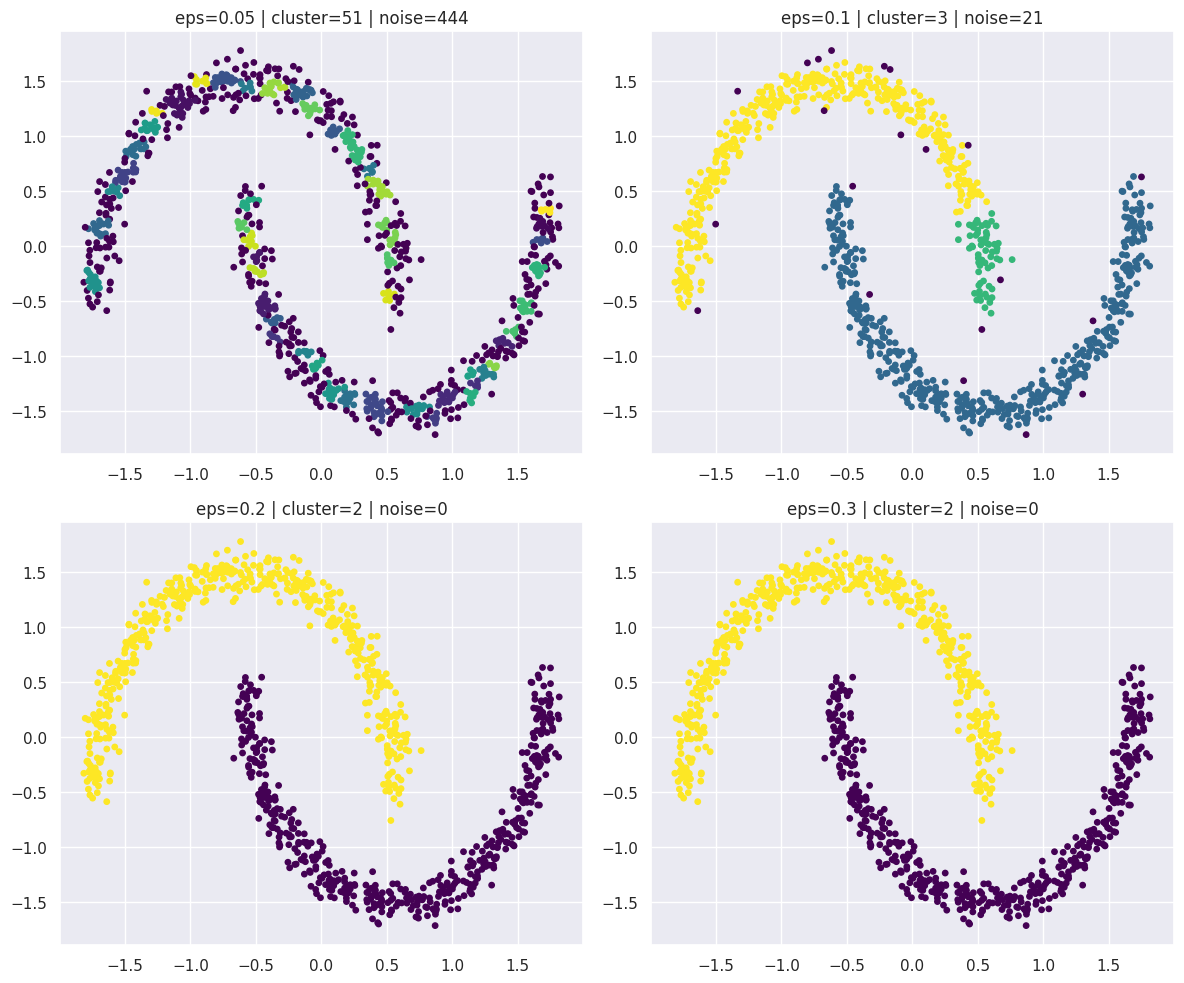

In [10]:
#visualisasi perbandingan variasi eps dan min_samples
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
eps_plot = [0.05, 0.1, 0.2, 0.3]

for ax, eps in zip(axes.flat, eps_plot):
    db_plot = DBSCAN(eps=eps, min_samples=5).fit(X)
    labels_plot = db_plot.labels_
    n_clusters_plot = len(set(labels_plot)) - (1 if -1 in labels_plot else 0)
    n_noise_plot = list(labels_plot).count(-1)

    ax.scatter(X[:, 0], X[:, 1], c=labels_plot, s=15, cmap='viridis')
    ax.set_title(f"eps={eps} | cluster={n_clusters_plot} | noise={n_noise_plot}")

plt.tight_layout()
plt.show()